In [ ]:
!pip install datasets matplotlib seaborn pandas numpy wordcloud umap-learn scikit-learn sentence-transformers tqdm -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

COLORS = {
    'gsm8k': '#4C72B0',
    'math':  '#DD8452',
    'accent': '#55A868',
    'highlight': '#C44E52'
}

print('Libraries loaded')

Libraries loaded


In [ ]:
from datasets import load_dataset

# GSM8K
print('Loading GSM8K...')
gsm8k_raw = load_dataset('openai/gsm8k', 'main')
gsm8k_train = gsm8k_raw['train'].to_pandas()
gsm8k_test  = gsm8k_raw['test'].to_pandas()
gsm8k = pd.concat([gsm8k_train, gsm8k_test], ignore_index=True)
gsm8k['source'] = 'GSM8K'
gsm8k['question_len'] = gsm8k['question'].str.split().str.len()
gsm8k['answer_len']   = gsm8k['answer'].str.split().str.len()
print(f'  GSM8K rows: {len(gsm8k):,}')

# MATH
print('Loading MATH...')
math_raw = load_dataset('nlile/hendrycks-MATH-benchmark')
math_train = math_raw['train'].to_pandas()
math_test  = math_raw['test'].to_pandas()
math_df = pd.concat([math_train, math_test], ignore_index=True)
math_df['source'] = 'MATH'
math_df['question_len'] = math_df['problem'].str.split().str.len()
math_df['answer_len']   = math_df['solution'].str.split().str.len()
math_df.rename(columns={'problem': 'question', 'solution': 'answer'}, inplace=True)
print(f'  MATH rows:  {len(math_df):,}')

print('\n Datasets ready')

Loading GSM8K...
  GSM8K rows: 8,792
Loading MATH...
  MATH rows:  12,500

 Datasets ready


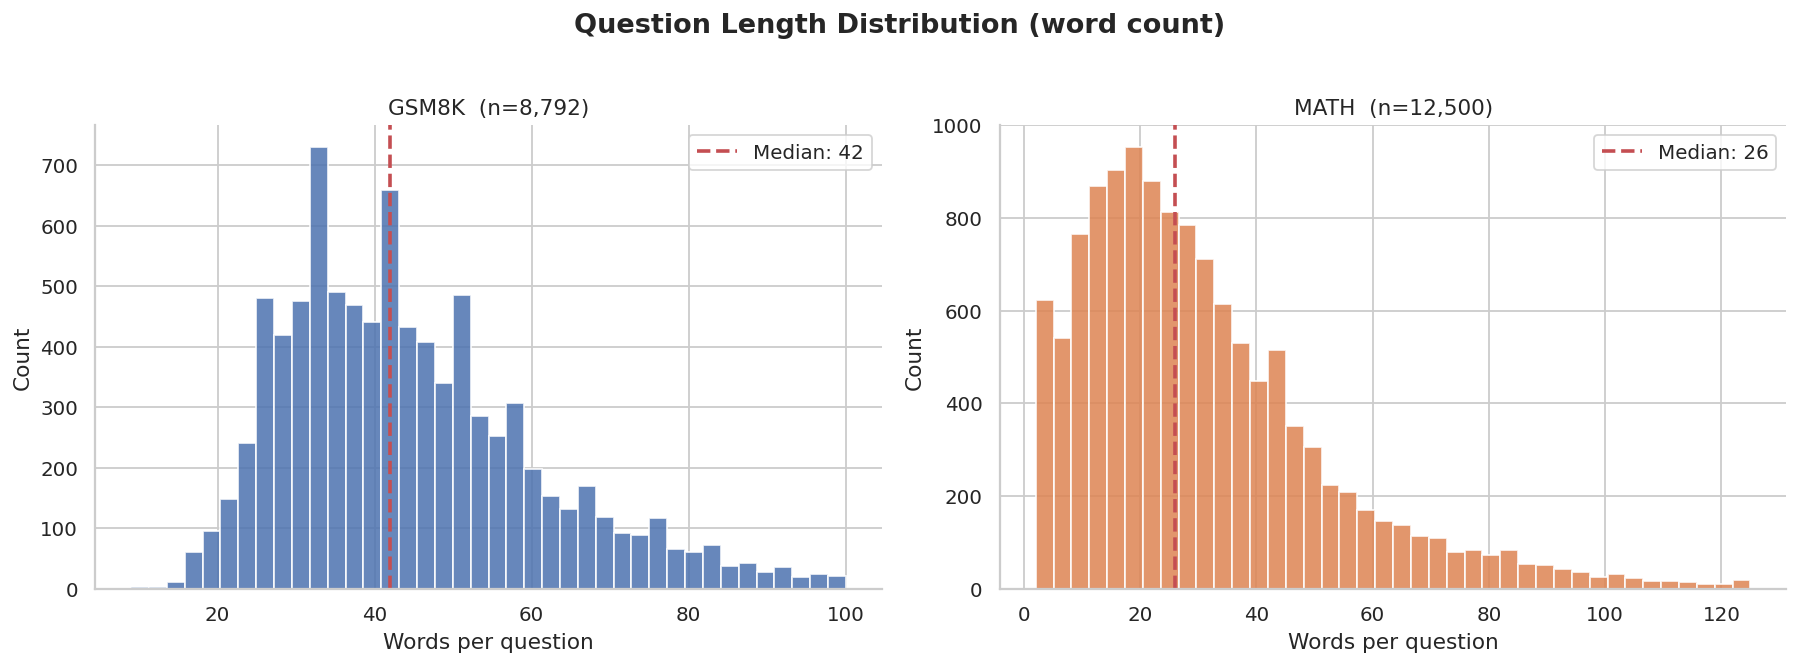

Saved viz1_question_length.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Question Length Distribution (word count)', fontsize=15, fontweight='bold', y=1.02)

datasets_info = [
    (gsm8k, 'GSM8K', COLORS['gsm8k'], axes[0]),
    (math_df, 'MATH',  COLORS['math'],  axes[1]),
]

for df, name, color, ax in datasets_info:
    data = df['question_len'].dropna()
    p99 = data.quantile(0.99)
    data_clipped = data[data <= p99]

    ax.hist(data_clipped, bins=40, color=color, edgecolor='white', alpha=0.85)

    med = data.median()
    ax.axvline(med, color=COLORS['highlight'], linewidth=2, linestyle='--', label=f'Median: {med:.0f}')

    ax.set_title(f'{name}  (n={len(df):,})', fontsize=12)
    ax.set_xlabel('Words per question')
    ax.set_ylabel('Count')
    ax.legend()
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('viz1_question_length.png', bbox_inches='tight')
plt.show()
print('Saved viz1_question_length.png')

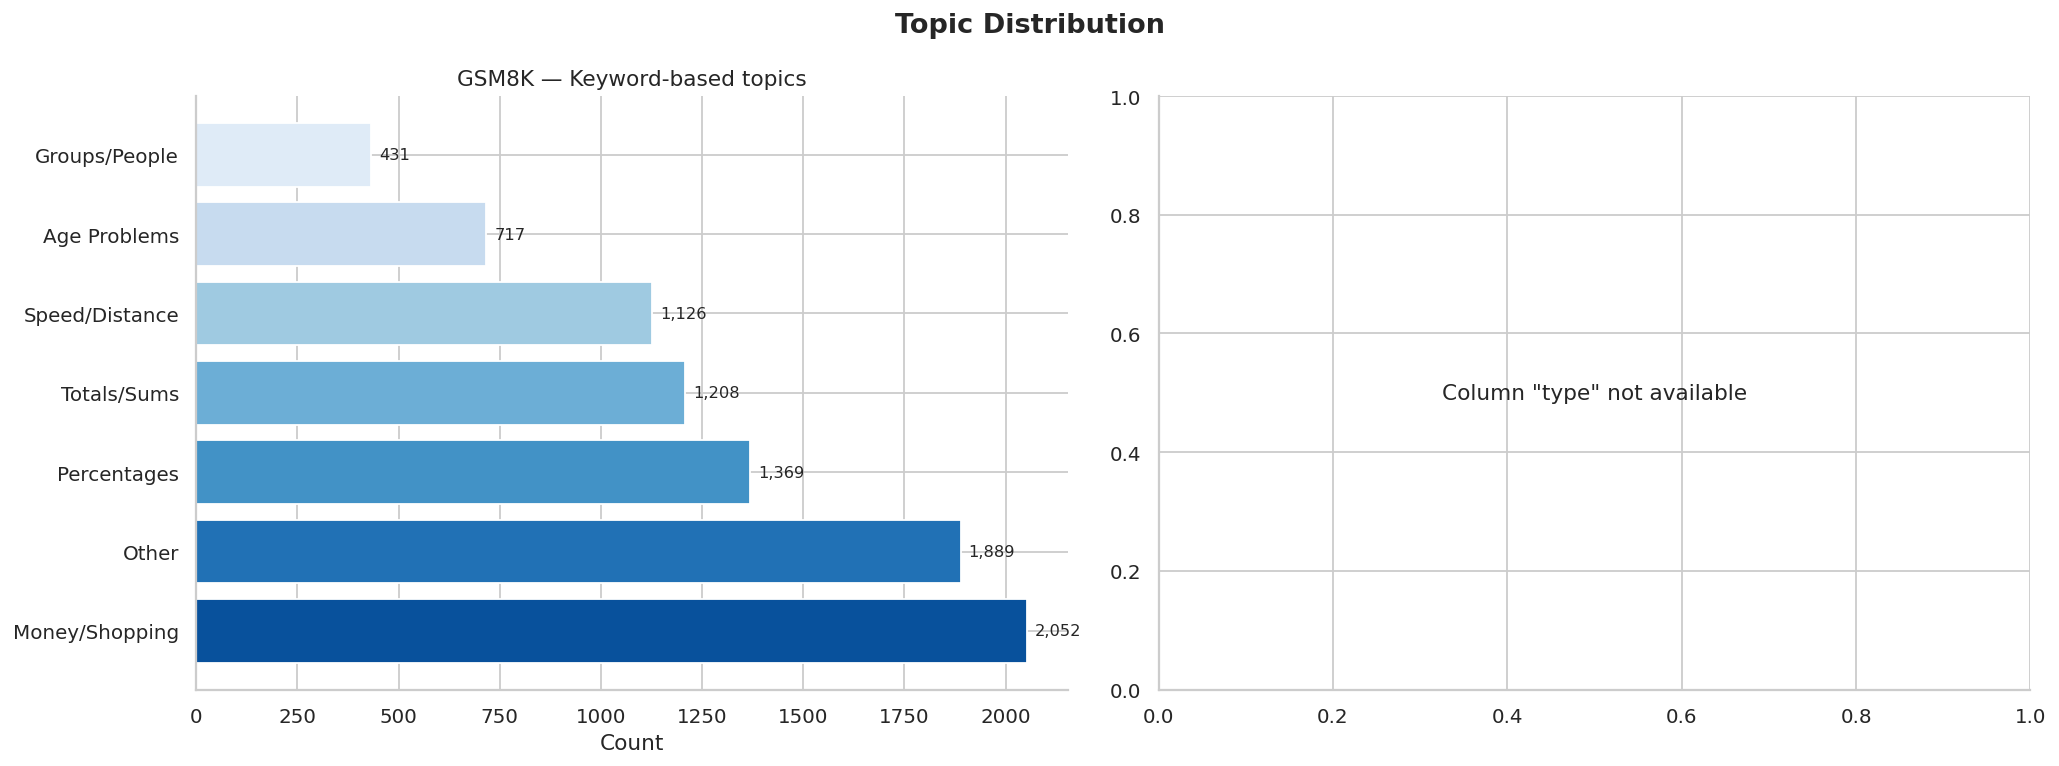

Saved viz2_topic_distribution.png


In [ ]:
# GSM8K topics: keyword-based heuristic
def classify_gsm8k(text):
    text = text.lower()
    if any(w in text for w in ['percent', '%', 'discount', 'tax', 'profit', 'loss', 'interest']):
        return 'Percentages'
    if any(w in text for w in ['speed', 'distance', 'hour', 'miles', 'travel', 'drove']):
        return 'Speed/Distance'
    if any(w in text for w in ['bought', 'sold', 'cost', 'price', 'pay', 'spent', 'dollar', '$']):
        return 'Money/Shopping'
    if any(w in text for w in ['total', 'altogether', 'sum', 'added', 'combined']):
        return 'Totals/Sums'
    if any(w in text for w in ['age', 'year', 'born', 'old']):
        return 'Age Problems'
    if any(w in text for w in ['group', 'team', 'class', 'student', 'people', 'friend']):
        return 'Groups/People'
    return 'Other'

gsm8k['topic'] = gsm8k['question'].apply(classify_gsm8k)
gsm8k_topics = gsm8k['topic'].value_counts()

# MATH topics: use the 'type' column directly
math_topics = math_df['type'].value_counts() if 'type' in math_df.columns else pd.Series(dtype=int)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Topic Distribution', fontsize=15, fontweight='bold')

# GSM8K
ax = axes[0]
bars = ax.barh(gsm8k_topics.index, gsm8k_topics.values,
               color=sns.color_palette('Blues_r', len(gsm8k_topics)))
ax.set_title('GSM8K — Keyword-based topics', fontsize=12)
ax.set_xlabel('Count')
for bar, val in zip(bars, gsm8k_topics.values):
    ax.text(val + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
sns.despine(ax=ax)

# MATH
ax = axes[1]
if len(math_topics):
    bars = ax.barh(math_topics.index, math_topics.values,
                   color=sns.color_palette('Oranges_r', len(math_topics)))
    ax.set_title('MATH — Subject areas', fontsize=12)
    ax.set_xlabel('Count')
    for bar, val in zip(bars, math_topics.values):
        ax.text(val + 20, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9)
else:
    ax.text(0.5, 0.5, 'Column "type" not available', ha='center', va='center', transform=ax.transAxes)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('viz2_topic_distribution.png', bbox_inches='tight')
plt.show()
print('Saved viz2_topic_distribution.png')

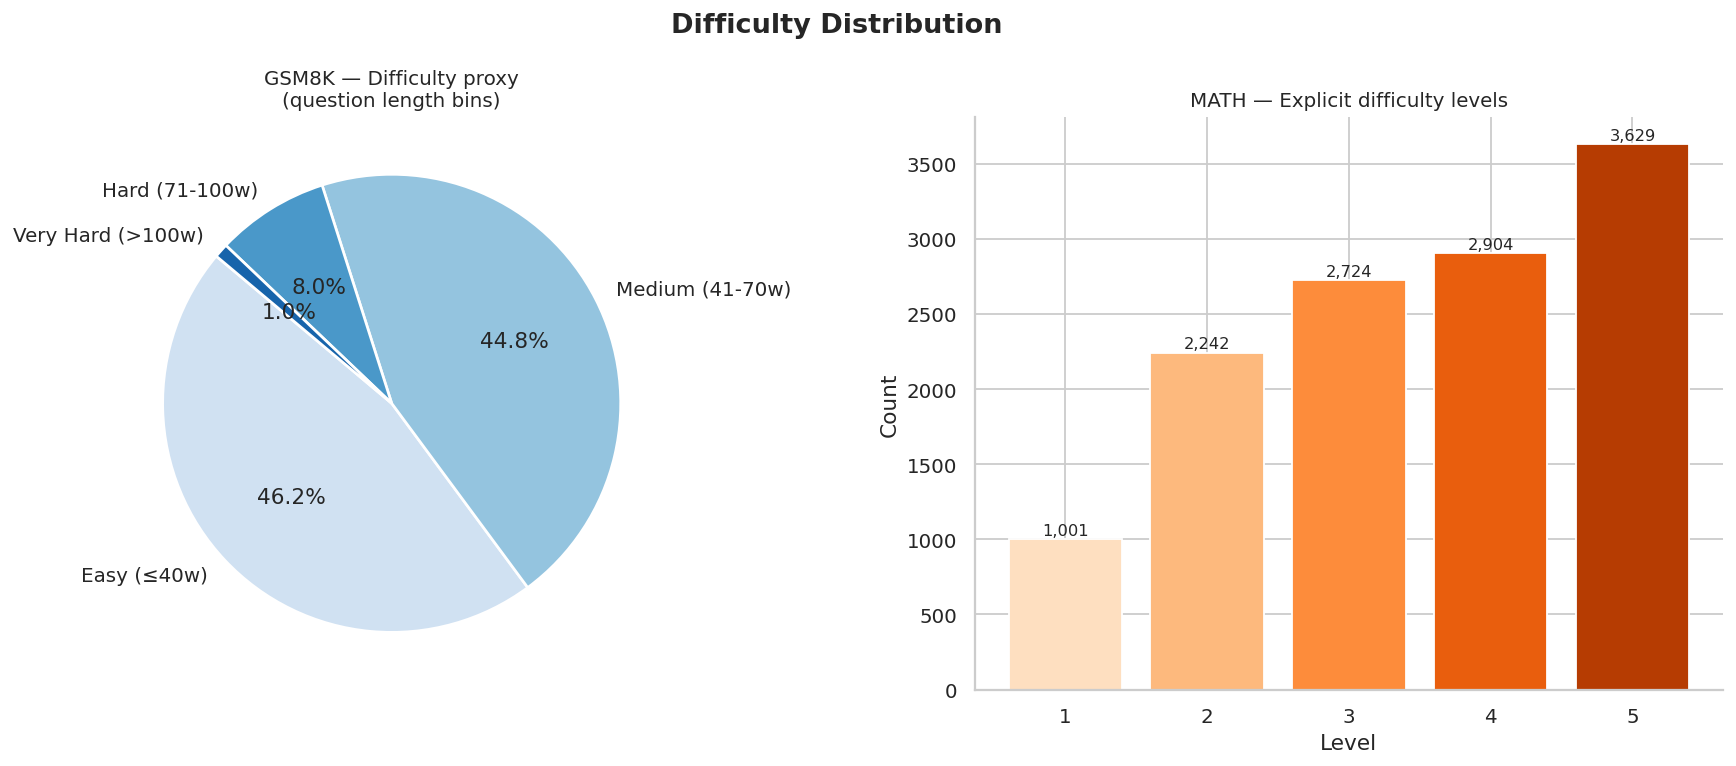

Saved viz3_difficulty.png


In [ ]:
# GSM8K proxy difficulty: question word count (longer ≈ harder)
gsm8k['difficulty_proxy'] = pd.cut(
    gsm8k['question_len'],
    bins=[0, 40, 70, 100, np.inf],
    labels=['Easy (≤40w)', 'Medium (41-70w)', 'Hard (71-100w)', 'Very Hard (>100w)']
)

# MATH uses explicit 'level' column
math_has_level = 'level' in math_df.columns
if math_has_level:
    math_difficulty = math_df['level'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Difficulty Distribution', fontsize=15, fontweight='bold')

# GSM8K pie
gsm8k_diff = gsm8k['difficulty_proxy'].value_counts()
axes[0].pie(
    gsm8k_diff.values,
    labels=gsm8k_diff.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('Blues', len(gsm8k_diff)),
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title('GSM8K — Difficulty proxy\n(question length bins)', fontsize=11)

# MATH bar
if math_has_level:
    axes[1].bar(
        math_difficulty.index.astype(str),
        math_difficulty.values,
        color=sns.color_palette('Oranges', len(math_difficulty)),
        edgecolor='white'
    )
    axes[1].set_title('MATH — Explicit difficulty levels', fontsize=11)
    axes[1].set_xlabel('Level')
    axes[1].set_ylabel('Count')
    for i, v in enumerate(math_difficulty.values):
        axes[1].text(i, v + 30, f'{v:,}', ha='center', fontsize=9)
    sns.despine(ax=axes[1])
else:
    axes[1].text(0.5, 0.5, 'No explicit level column found', ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig('viz3_difficulty.png', bbox_inches='tight')
plt.show()
print('Saved viz3_difficulty.png')

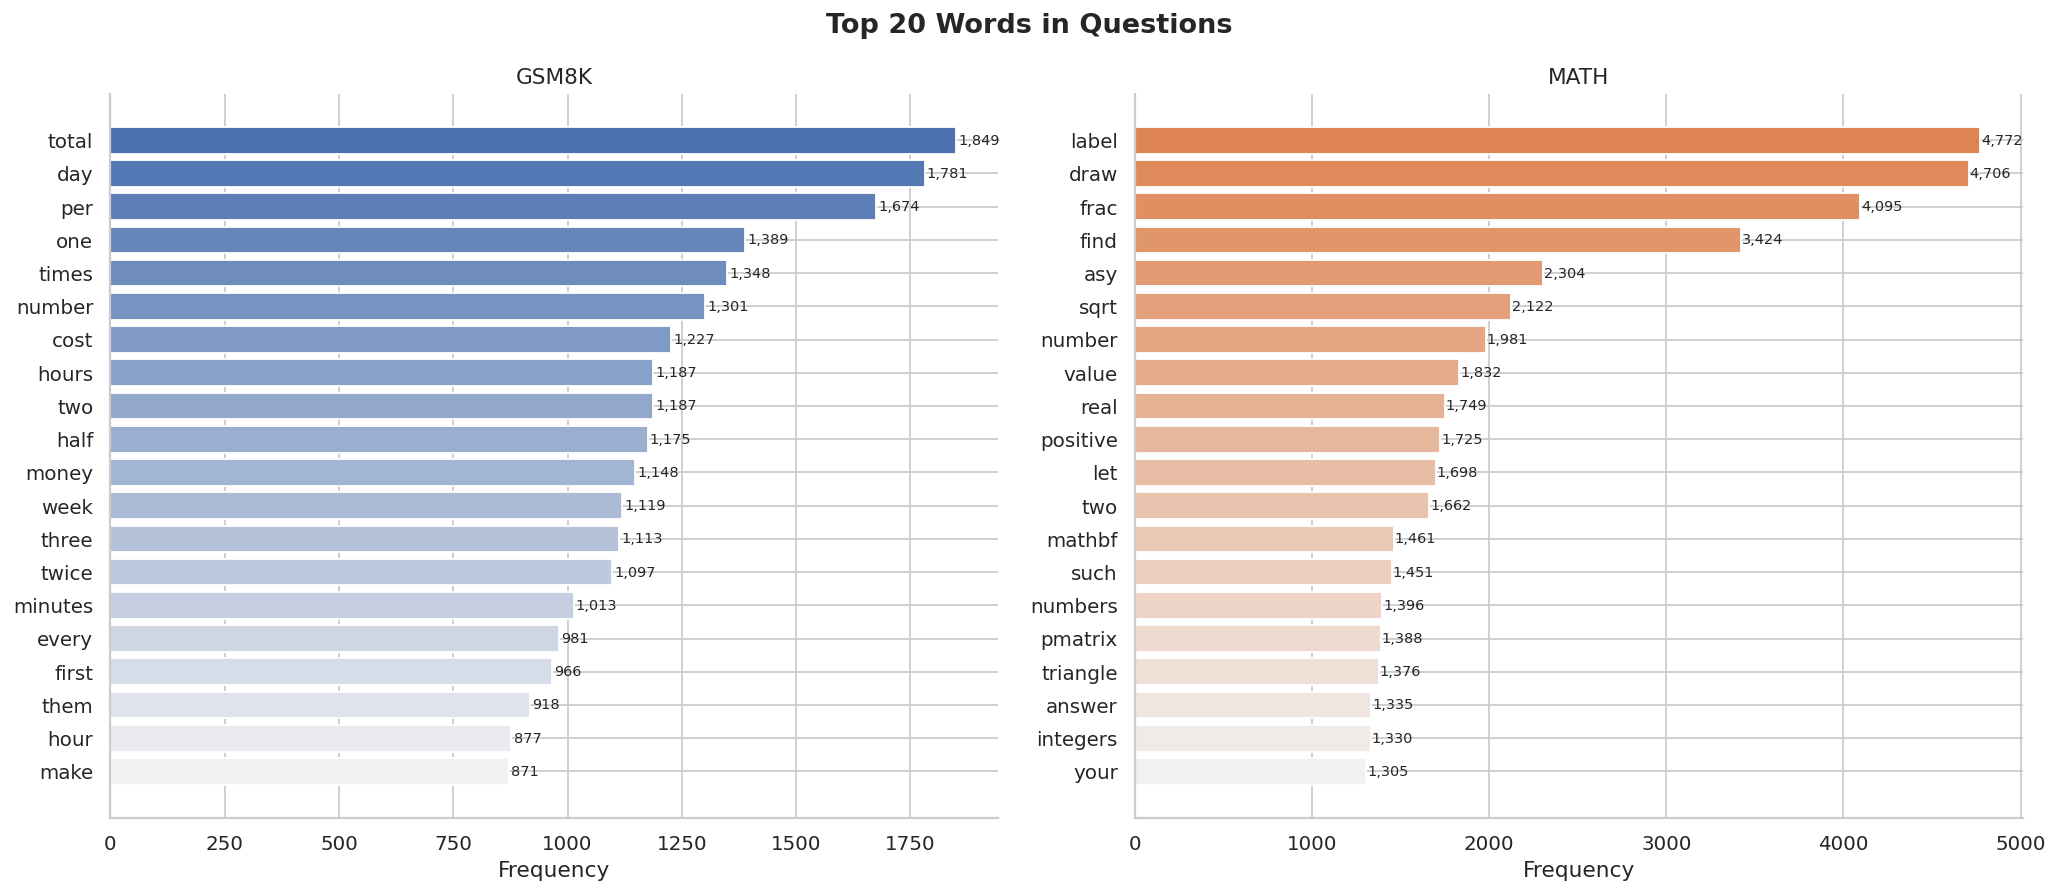

Saved viz4_word_frequency.png


In [ ]:
from collections import Counter

STOPWORDS = set([
    'the','a','an','is','are','was','were','be','been','being',
    'have','has','had','do','does','did','will','would','could',
    'should','may','might','shall','can','to','of','in','for',
    'on','with','at','by','from','as','it','its','this','that',
    'he','she','they','we','you','i','his','her','their','our',
    'and','or','but','not','no','so','if','then','there','each',
    'all','more','than','how','many','much','what','which','who'
])

def top_words(series, n=20):
    tokens = ' '.join(series.fillna('')).lower()
    tokens = re.sub(r'[^a-z\s]', ' ', tokens).split()
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    return Counter(tokens).most_common(n)

gsm8k_words = top_words(gsm8k['question'])
math_words  = top_words(math_df['question'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Top 20 Words in Questions', fontsize=15, fontweight='bold')

for ax, words, name, color in [
    (axes[0], gsm8k_words, 'GSM8K', COLORS['gsm8k']),
    (axes[1], math_words,  'MATH',  COLORS['math'])
]:
    labels, counts = zip(*words)
    palette = sns.light_palette(color, n_colors=len(labels), reverse=True)
    bars = ax.barh(list(reversed(labels)), list(reversed(counts)), color=list(reversed(palette)))
    ax.set_title(f'{name}', fontsize=12)
    ax.set_xlabel('Frequency')
    for bar, val in zip(bars, reversed(counts)):
        ax.text(val + 5, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=8)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('viz4_word_frequency.png', bbox_inches='tight')
plt.show()
print('Saved viz4_word_frequency.png')

Encoding 3,000 questions...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Running UMAP...


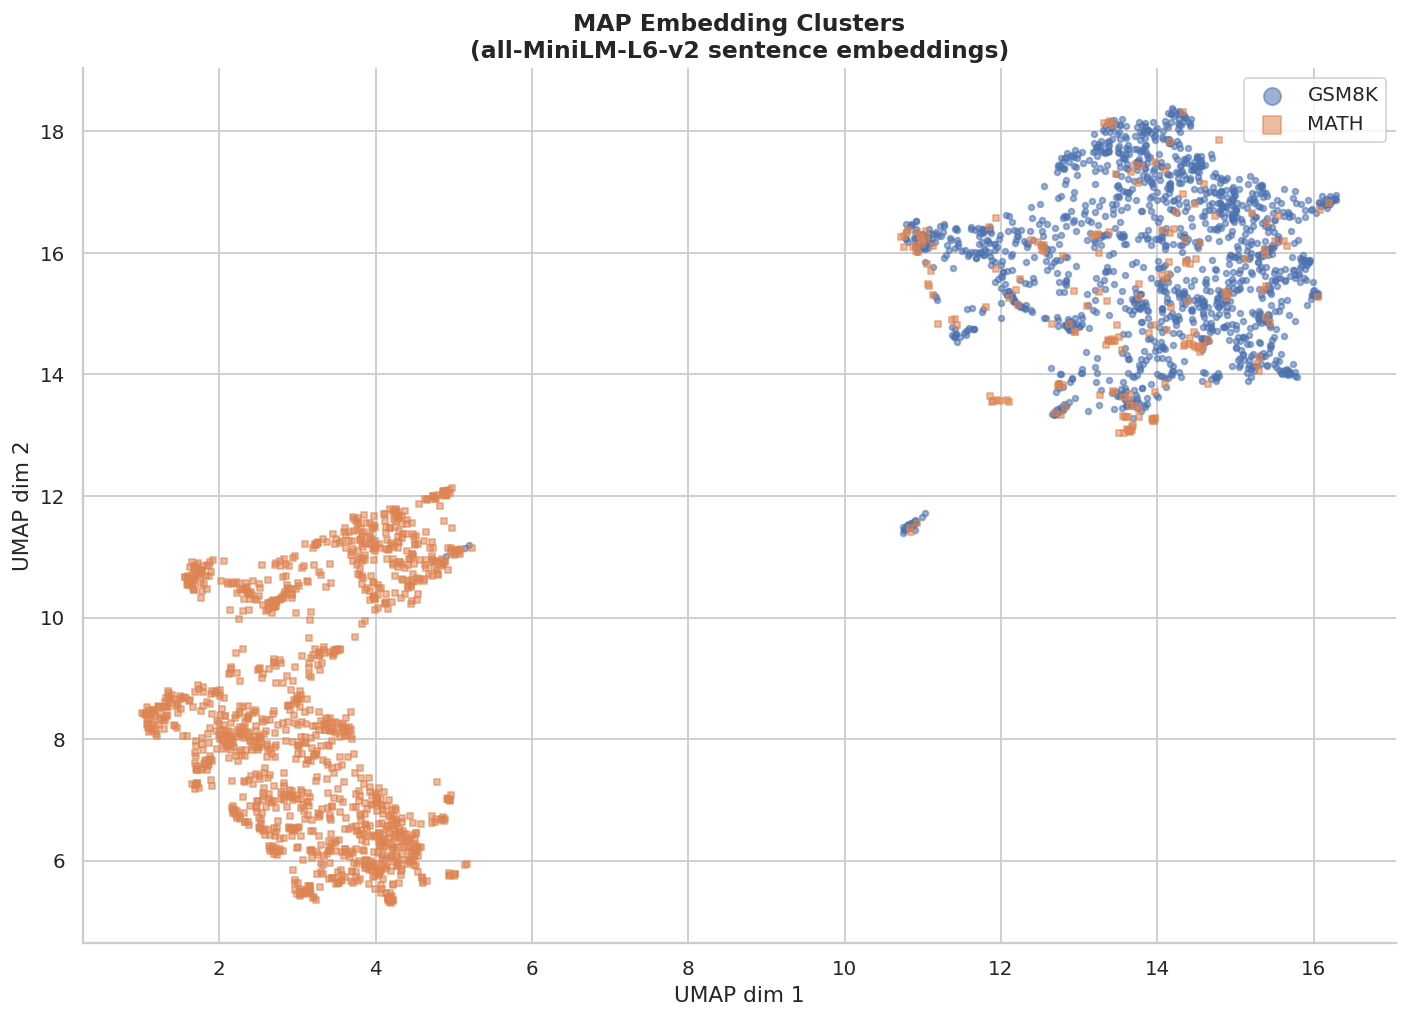

Saved viz5_umap_clusters.png


In [ ]:
from sentence_transformers import SentenceTransformer
import umap
from tqdm.auto import tqdm

N_SAMPLE = 1500  # increase for more detail, decrease for speed

# Sample
gsm8k_sample = gsm8k.sample(min(N_SAMPLE, len(gsm8k)), random_state=42)
math_sample  = math_df.sample(min(N_SAMPLE, len(math_df)), random_state=42)

all_questions = pd.concat([
    gsm8k_sample[['question', 'source']],
    math_sample[['question',  'source']]
], ignore_index=True)

print(f'Encoding {len(all_questions):,} questions...')
model = SentenceTransformer('all-MiniLM-L6-v2')  # fast, small
embeddings = model.encode(all_questions['question'].tolist(),
                           batch_size=64, show_progress_bar=True,
                           convert_to_numpy=True)

print('Running UMAP...')
reducer = umap.UMAP(n_components=2, random_state=42,
                    n_neighbors=20, min_dist=0.1, metric='cosine')
embedding_2d = reducer.fit_transform(embeddings)

all_questions['umap_x'] = embedding_2d[:, 0]
all_questions['umap_y'] = embedding_2d[:, 1]

# ── Scatter plot ──
fig, ax = plt.subplots(figsize=(11, 8))
for src, color, marker in [
    ('GSM8K', COLORS['gsm8k'], 'o'),
    ('MATH',  COLORS['math'],  's')
]:
    sub = all_questions[all_questions['source'] == src]
    ax.scatter(sub['umap_x'], sub['umap_y'],
               c=color, s=10, alpha=0.55, label=src, marker=marker)

ax.set_title('MAP Embedding Clusters\n(all-MiniLM-L6-v2 sentence embeddings)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('UMAP dim 1')
ax.set_ylabel('UMAP dim 2')
ax.legend(markerscale=3, fontsize=11)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('viz5_umap_clusters.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved viz5_umap_clusters.png')

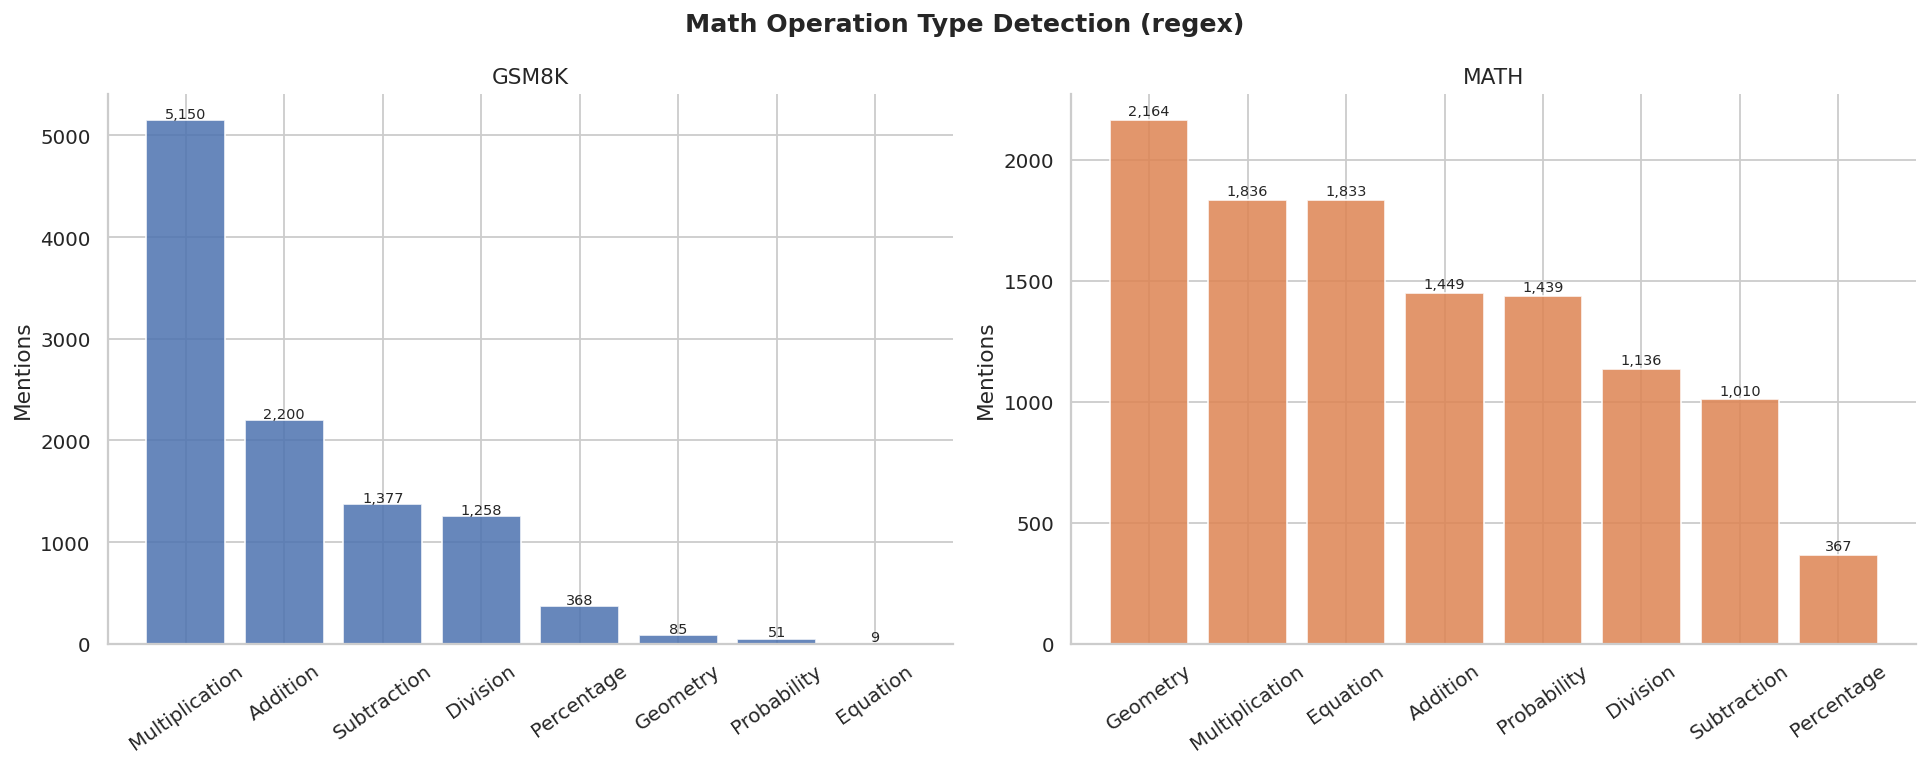

In [27]:
OPERATIONS = {
    'Addition':       r'\badd(ed|ing)?\b|\bplus\b|\bsum\b|\btotal\b|\bmore than\b',
    'Subtraction':    r'\bsubtract|\bminus\b|\bdifference\b|\bless than\b|\bremaining\b|\bleft\b',
    'Multiplication': r'\bmultiply|\btimes\b|\bproduct\b|\beach\b|\bper\b|\btwice\b|\bdouble\b',
    'Division':       r'\bdivide|\bquotient\b|\bsplit\b|\bshare\b|\bhalf\b|\bfraction\b',
    'Percentage':     r'\bpercent|\b%\b|\brate\b|\bratio\b',
    'Equation':       r'\bequation\b|\bsolve\b|\bvariable\b|\bexpress\b|\bformula\b',
    'Geometry':       r'\barea\b|\bvolume\b|\bperimeter\b|\bangle\b|\bcircle\b|\btriangle\b',
    'Probability':    r'\bprobability\b|\blikely\b|\brandom\b|\bchance\b|\bpossible\b',
}

def op_counts(series):
    all_ops = [op for text in series for op, pat in OPERATIONS.items() if re.search(pat, str(text).lower())]
    return pd.Series(Counter(all_ops)).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Math Operation Type Detection (regex)', fontsize=14, fontweight='bold')

for ax, series, name, color in [
    (axes[0], gsm8k['question'],   'GSM8K', COLORS['gsm8k']),
    (axes[1], math_df['question'], 'MATH',  COLORS['math'])
]:
    ops = op_counts(series)
    bars = ax.bar(ops.index, ops.values, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(name, fontsize=12); ax.set_ylabel('Mentions')
    ax.tick_params(axis='x', rotation=35)
    for bar, val in zip(bars, ops.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 20, f'{val:,}', ha='center', fontsize=8)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('viz11_operation_types.png', bbox_inches='tight')
plt.show()

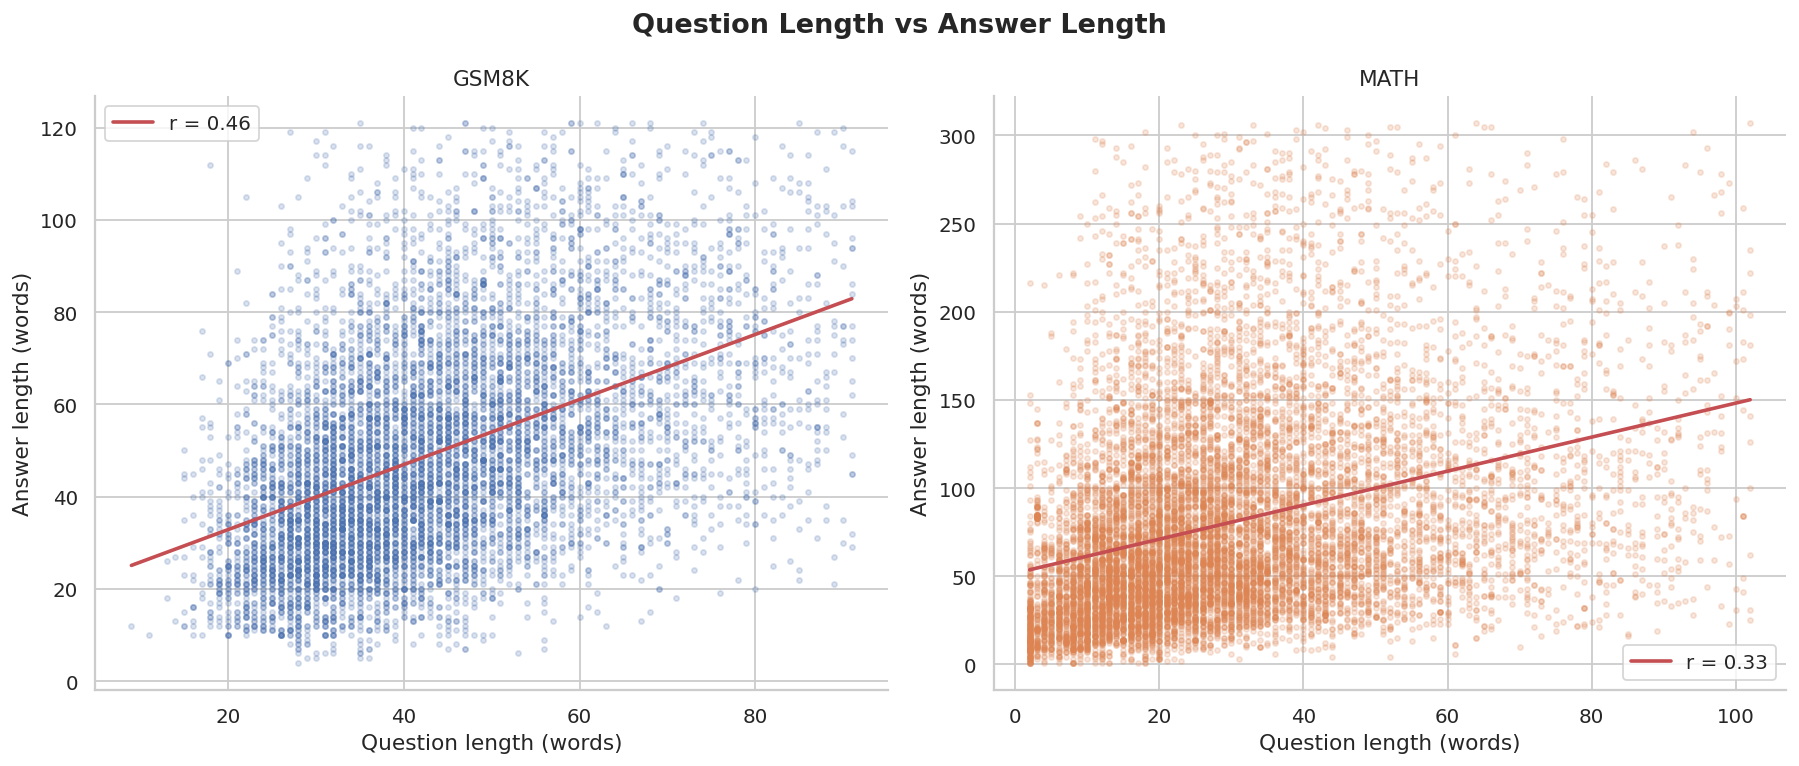

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Question Length vs Answer Length', fontsize=15, fontweight='bold')

for ax, df, name, color in [
    (axes[0], gsm8k,   'GSM8K', COLORS['gsm8k']),
    (axes[1], math_df, 'MATH',  COLORS['math'])
]:
    sub = df[['question_len','answer_len']].dropna()
    sub = sub[
        (sub['question_len'] <= sub['question_len'].quantile(0.98)) &
        (sub['answer_len']   <= sub['answer_len'].quantile(0.98))
    ]
    ax.scatter(sub['question_len'], sub['answer_len'], alpha=0.2, s=8, color=color)
    m, b = np.polyfit(sub['question_len'], sub['answer_len'], 1)
    xr = np.linspace(sub['question_len'].min(), sub['question_len'].max(), 100)
    r  = sub['question_len'].corr(sub['answer_len'])
    ax.plot(xr, m*xr + b, color=COLORS['highlight'], lw=2, label=f'r = {r:.2f}')
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Question length (words)'); ax.set_ylabel('Answer length (words)')
    ax.legend(fontsize=11); sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('viz07_qlen_vs_alen.png', bbox_inches='tight')
plt.show()

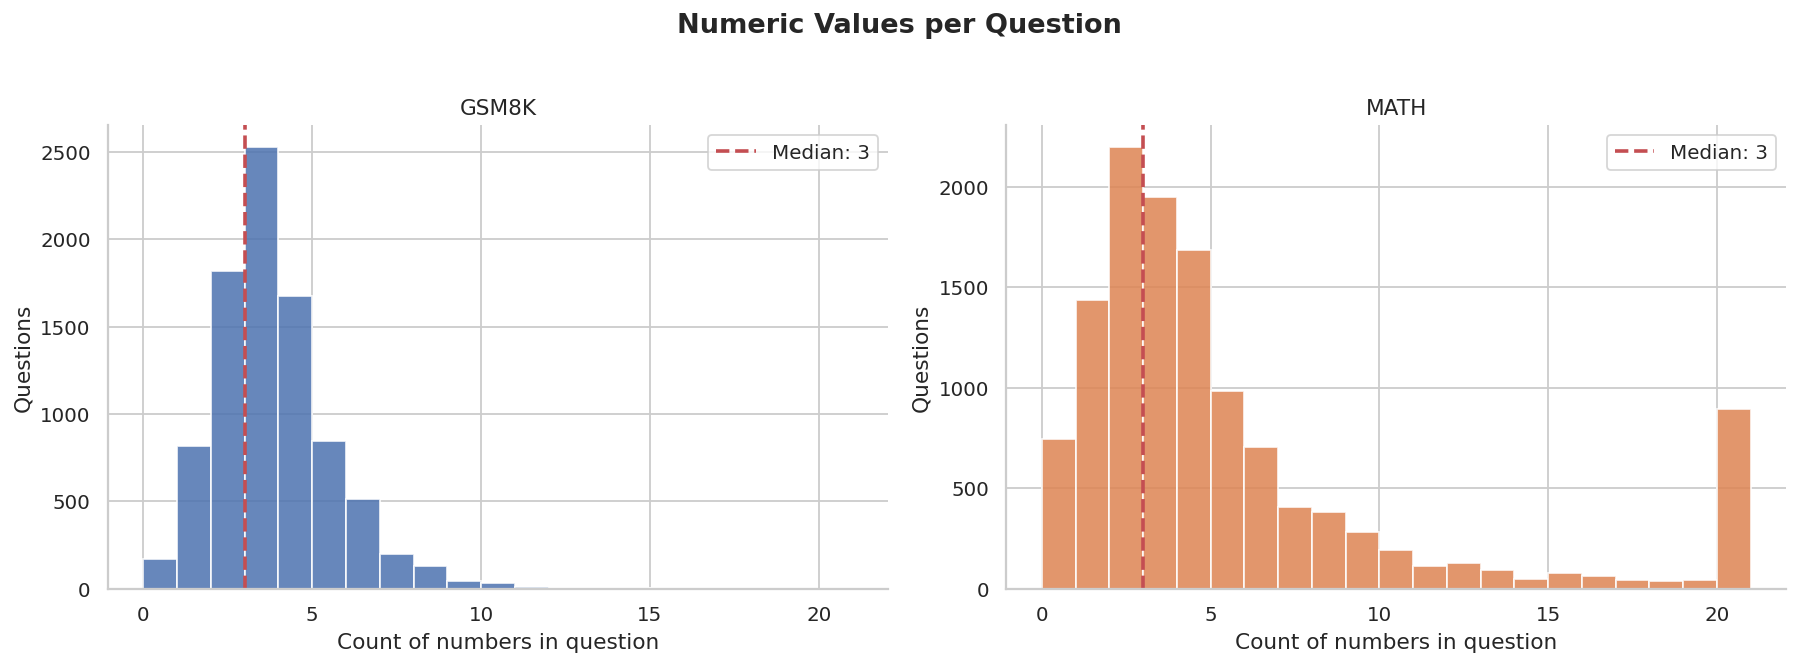

In [29]:
def count_numbers(text):
    return len(re.findall(r'\b\d+\.?\d*\b', str(text)))

gsm8k['num_count']   = gsm8k['question'].apply(count_numbers)
math_df['num_count'] = math_df['question'].apply(count_numbers)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Numeric Values per Question', fontsize=15, fontweight='bold', y=1.02)

for ax, df, name, color in [
    (axes[0], gsm8k,   'GSM8K', COLORS['gsm8k']),
    (axes[1], math_df, 'MATH',  COLORS['math'])
]:
    data = df['num_count'].clip(upper=20)
    ax.hist(data, bins=range(0, 22), color=color, edgecolor='white', alpha=0.85)
    med = df['num_count'].median()
    ax.axvline(med, color=COLORS['highlight'], lw=2, ls='--', label=f'Median: {med:.0f}')
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Count of numbers in question'); ax.set_ylabel('Questions')
    ax.legend(); sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('viz09_number_count.png', bbox_inches='tight')
plt.show()
